# Task 3 — Phase 1: Accent Head + Swap + Classifier
MirrorSpeech Project | Person 3

This notebook implements the three accent components and integrates them with Task 1 (DataLoader) and Task 2 (Whisper + LoRA + ContentHead) outputs.

### What this notebook does:
1. Mounts Google Drive and loads real audio data (from Task 1 setup)
2. Loads Whisper + LoRA + ContentHead (from Task 2)
3. Builds and tests AccentProjectionHead → accent_vec [B, 128]
4. Builds and tests accent_swap() → swapped [B, T, 384]
5. Builds and tests AccentClassifier → probs [B, 5]
6. Runs full end-to-end integration test with real audio

### Outputs handed to the team:
- swapped [B, T, 384] → Person 2 (Phase 2 Re-encoder input)
- accent_probs [B, 5] → Person 4 (accent classification loss)

---
## Cell 1 — Install packages

In [ ]:
import subprocess, sys

packages = [
    'transformers',
    'peft',
    'torchaudio',
    'soundfile',
    'accelerate',
]

for pkg in packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

print('All packages installed')

All packages installed


---
## Cell 2 — Imports and device setup

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchaudio
import os
import json
import zipfile
import numpy as np
import warnings
warnings.filterwarnings('ignore')

from transformers import WhisperProcessor, WhisperModel
from peft import LoraConfig, get_peft_model
from collections import Counter

# ── Device ──────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print('=' * 50)
print('TASK 3 — PHASE 1: ACCENT COMPONENTS')
print('=' * 50)
print(f'PyTorch     : {torch.__version__}')
print(f'Torchaudio  : {torchaudio.__version__}')
print(f'Device      : {device}')
if torch.cuda.is_available():
    print(f'GPU name    : {torch.cuda.get_device_name(0)}')
print('=' * 50)

TASK 3 — PHASE 1: ACCENT COMPONENTS
PyTorch     : 2.10.0+cpu
Torchaudio  : 2.10.0+cpu
Device      : cpu


---
## Cell 3 — Mount Google Drive and extract L2-ARCTIC data
> Same Drive structure used by Task 1 and Task 2. Skips speakers already extracted.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# ── Paths (same as Task 1 & Task 2) ─────────────────────────────
DRIVE_ZIP_DIR = '/content/drive/MyDrive/MirrorSpeech/l2arctic_zips'
EXTRACT_PATH  = '/content/data/l2arctic'
SPLITS_DIR    = '/content/drive/MyDrive/MirrorSpeech/splits'
LIBRI_BASE = '/content/drive/MyDrive/MirrorSpeech/librispeech/LibriSpeech 2/dev-clean'



SPEAKERS = [
    'RRBI', 'SVBI', 'TNI',   'NJS',    # Indian
    'HQTV', 'MBMPS','NCC',  'TXHC',   # Mandarin
    'HJK',  'HKK',  'YDCK', 'YKWK',   # Korean
    'ABA',  'YBAA', 'SKA',  'ZHAA',   # Arabic
]

os.makedirs(EXTRACT_PATH, exist_ok=True)

for spk in SPEAKERS:
    zip_path = f'{DRIVE_ZIP_DIR}/{spk}.zip'
    out_path = f'{EXTRACT_PATH}/{spk}'
    if os.path.exists(out_path):
        print(f'  {spk} already extracted')
        continue
    if not os.path.exists(zip_path):
        print(f' {spk}.zip not found in Drive — skipping')
        continue
    print(f'  Extracting {spk}...')
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall(EXTRACT_PATH)

print(f'\nAll speakers extracted to {EXTRACT_PATH}')

Mounted at /content/drive
  Extracting RRBI...
  Extracting SVBI...
  Extracting TNI...
  Extracting NJS...
  Extracting HQTV...
  Extracting MBMPS...
  Extracting NCC...
  Extracting TXHC...
  Extracting HJK...
  Extracting HKK...
  Extracting YDCK...
  Extracting YKWK...
  Extracting ABA...
  Extracting YBAA...
  Extracting SKA...
  Extracting ZHAA...

All speakers extracted to /content/data/l2arctic


---
## Cell 4 — Load dataset splits
> Reads the train/val/test JSON splits created by Task 1 and fixes paths for Colab.

In [ ]:
print("LIBRI_BASE =", LIBRI_BASE)
test_fname = "2803-161169-0006.flac"
spk, chap, _ = test_fname.split('-', 2)
print(os.path.join(LIBRI_BASE, spk, chap, test_fname))
print(os.path.exists(os.path.join(LIBRI_BASE, spk, chap, test_fname)))

LIBRI_BASE = /content/drive/MyDrive/MirrorSpeech/librispeech/LibriSpeech 2/dev-clean
/content/drive/MyDrive/MirrorSpeech/librispeech/LibriSpeech 2/dev-clean/2803/161169/2803-161169-0006.flac
True


In [ ]:
def load_and_fix_paths(split_name):
    path = f'{SPLITS_DIR}/{split_name}.json'
    records = json.load(open(path))

    for r in records:
        accent = str(r.get('accent', '')).lower()

        if accent in ['indian', 'mandarin', 'korean', 'arabic']:
            r['wav_path'] = os.path.join(
                EXTRACT_PATH,
                r['speaker'],
                'wav',
                os.path.basename(r['wav_path'])
            )

        elif accent == 'native':
            fname = os.path.basename(r['wav_path'])   # 2803-161169-0006.flac
            spk, chap, _ = fname.split('-', 2)
            r['wav_path'] = os.path.join(
                LIBRI_BASE,
                spk,
                chap,
                fname
            )

    return records

In [ ]:
def load_and_fix_paths(split_name):
    path = f'{SPLITS_DIR}/{split_name}.json'
    records = json.load(open(path))

    for r in records:
        aid = int(r['accent_id'])

        # L2-ARCTIC accents: 0=indian, 1=mandarin, 2=korean, 3=arabic
        if aid in [0, 1, 2, 3]:
            r['wav_path'] = os.path.join(
                EXTRACT_PATH,
                r['speaker'],
                'wav',
                os.path.basename(r['wav_path'])
            )

        # Native / LibriSpeech: 4=native
        elif aid == 4:
            fname = os.path.basename(r['wav_path'])   # 2803-161169-0006.flac
            spk, chap, _ = fname.split('-', 2)
            r['wav_path'] = os.path.join(LIBRI_BASE, spk, chap, fname)

    return records

In [ ]:
config        = json.load(open(f'{SPLITS_DIR}/config.json'))
train_records = load_and_fix_paths('train')
val_records   = load_and_fix_paths('val')
test_records  = load_and_fix_paths('test')

ACCENT_MAP    = {int(k): v for k, v in config['id_to_accent'].items()}
ACCENT_TO_ID  = {v: k for k, v in ACCENT_MAP.items()}

In [ ]:
native_samples = [r for r in train_records if r['accent_id'] == 4]
print(native_samples[0]['wav_path'])
print(os.path.exists(native_samples[0]['wav_path']))

/content/drive/MyDrive/MirrorSpeech/librispeech/LibriSpeech 2/dev-clean/2803/161169/2803-161169-0006.flac
True


In [ ]:
native_samples = [r for r in train_records if r['accent_id'] == 4]
print("Num native samples:", len(native_samples))
print("Example native path:", native_samples[0]['wav_path'])
print("Exists:", os.path.exists(native_samples[0]['wav_path']))
print("Sample native record keys:", native_samples[0].keys())

Num native samples: 2167
Example native path: /content/drive/MyDrive/MirrorSpeech/librispeech/LibriSpeech 2/dev-clean/2803/161169/2803-161169-0006.flac
Exists: True
Sample native record keys: dict_keys(['wav_path', 'transcript', 'accent_id', 'speaker'])


In [ ]:
print(set(r['accent_id'] for r in train_records))

{0, 1, 2, 3, 4}


---
## Cell 5 — Load Whisper + LoRA + ContentHead (Task 2)
> Copied from Task 2. Whisper is frozen; LoRA adapters are injected. ContentHead projects encoder output from 768 → 256.

In [ ]:
# ── Whisper processor (handles audio → mel spectrogram) ──────────
processor = WhisperProcessor.from_pretrained('openai/whisper-small')
print('WhisperProcessor loaded')

# ── Whisper model (freeze all weights) ───────────────────────────
model = WhisperModel.from_pretrained('openai/whisper-small')
for param in model.parameters():
    param.requires_grad = False

total_params = sum(p.numel() for p in model.parameters())
print(f'Whisper loaded  — {total_params:,} total params (all frozen)')

# ── Inject LoRA adapters ─────────────────────────────────────────
lora_config = LoraConfig(
    r              = 16,
    lora_alpha     = 32,
    target_modules = ['q_proj', 'v_proj'],
    lora_dropout   = 0.1,
    bias           = 'none'
)
model = get_peft_model(model, lora_config)
model = model.to(device)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
pct       = trainable / total_params * 100
print(f'LoRA injected   — {trainable:,} trainable params ({pct:.2f}% of total)')
assert pct < 1.0, f'LoRA trainable% should be < 1%, got {pct:.2f}%'


# ── Content Head (Task 2) ────────────────────────────────────────
class ContentHead(nn.Module):
    """
    Projects Whisper encoder output from 768 → 256.
    Input  : [B, T, 768]  (encoder output)
    Output : [B, T, 256]  (content representation)
    """
    def __init__(self, input_dim=768, output_dim=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, output_dim),
            nn.LayerNorm(output_dim),
            nn.ReLU()
        )

    def forward(self, encoder_output):
        return self.net(encoder_output)


content_head = ContentHead().to(device)
print('\nContentHead built : Linear(768→256) → LayerNorm → ReLU')
print('\nTask 2 components ready')

preprocessor_config.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

WhisperProcessor loaded


model.safetensors:   0%|          | 0.00/967M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

Whisper loaded  — 241,734,912 total params (all frozen)


LoRA injected   — 1,769,472 trainable params (0.73% of total)

ContentHead built : Linear(768→256) → LayerNorm → ReLU

Task 2 components ready


---
## Cell 6 — Task 3: AccentProjectionHead
> Takes Whisper encoder output `[B, T, 768]`, mean-pools over time, outputs accent vector `[B, 128]`.

In [ ]:
class AccentProjectionHead(nn.Module):
    """
    Extracts a fixed-size accent embedding from the encoder output.

    Input  : encoder_output  [B, T, 768]
    Output : accent_vector   [B, 128]

    Steps:
      1. Linear(768 → 128)
      2. LayerNorm
      3. ReLU
      4. Mean-pool over time dimension T → collapse [B, T, 128] to [B, 128]
    """
    def __init__(self, input_dim=768, accent_dim=128):
        super().__init__()
        self.linear     = nn.Linear(input_dim, accent_dim)
        self.layer_norm = nn.LayerNorm(accent_dim)
        self.relu       = nn.ReLU()
        print(f'  AccentProjectionHead: Linear({input_dim}→{accent_dim}) → LayerNorm → ReLU → MeanPool')

    def forward(self, encoder_output):
        projected  = self.linear(encoder_output)      # [B, T, 128]
        normalized = self.layer_norm(projected)        # [B, T, 128]
        activated  = self.relu(normalized)             # [B, T, 128]
        accent_vec = torch.mean(activated, dim=1)      # [B, 128]  ← mean over time
        return accent_vec


# ── Quick shape test ─────────────────────────────────────────────
print('Testing AccentProjectionHead...')
accent_head  = AccentProjectionHead().to(device)

dummy_enc    = torch.randn(4, 100, 768).to(device)  # [B=4, T=100, dim=768]
dummy_accent = accent_head(dummy_enc)

print(f'  Input  : {dummy_enc.shape}')
print(f'  Output : {dummy_accent.shape}  ← should be [4, 128]')
assert dummy_accent.shape == (4, 128), f'Expected (4,128), got {dummy_accent.shape}'
print('\nAccentProjectionHead — shape test passed')

Testing AccentProjectionHead...
  AccentProjectionHead: Linear(768→128) → LayerNorm → ReLU → MeanPool
  Input  : torch.Size([4, 100, 768])
  Output : torch.Size([4, 128])  ← should be [4, 128]

AccentProjectionHead — shape test passed


---
## Cell 7 — Task 3: accent_swap function
> Concatenates content vector `[B, T, 256]` with accent vector `[B, 128]` → swapped `[B, T, 384]`.

In [ ]:
def accent_swap(content_vector, accent_vector):
    """
    Combines the content representation with the accent embedding.
    This is the core of the LCMA cycle — allows accent to be swapped
    while content stays fixed.

    Args:
        content_vector : [B, T, 256]  — from ContentHead (Task 2)
        accent_vector  : [B, 128]     — from AccentProjectionHead

    Returns:
        swapped        : [B, T, 384]  — concatenated along feature dim
                         (256 content + 128 accent = 384)
    """
    # Expand accent from [B, 128] to [B, T, 128] to match content's time dim
    accent_expanded = accent_vector.unsqueeze(1)                    # [B, 1, 128]
    accent_expanded = accent_expanded.repeat(1, content_vector.size(1), 1)  # [B, T, 128]

    # Concatenate content and accent along feature dimension
    swapped = torch.cat([content_vector, accent_expanded], dim=-1)  # [B, T, 384]
    return swapped


# ── Quick shape test ─────────────────────────────────────────────
print('Testing accent_swap...')
dummy_content = torch.randn(4, 100, 256).to(device)  # [B=4, T=100, content_dim=256]
dummy_acc_vec = torch.randn(4, 128).to(device)        # [B=4, accent_dim=128]

dummy_swapped = accent_swap(dummy_content, dummy_acc_vec)

print(f'  content_vector : {dummy_content.shape}')
print(f'  accent_vector  : {dummy_acc_vec.shape}')
print(f'  swapped output : {dummy_swapped.shape}  ← should be [4, 100, 384]')
assert dummy_swapped.shape == (4, 100, 384), f'Expected (4,100,384), got {dummy_swapped.shape}'
print('\naccent_swap — shape test passed')
print('   Note: 256 (content) + 128 (accent) = 384 ✓')

Testing accent_swap...
  content_vector : torch.Size([4, 100, 256])
  accent_vector  : torch.Size([4, 128])
  swapped output : torch.Size([4, 100, 384])  ← should be [4, 100, 384]

accent_swap — shape test passed
   Note: 256 (content) + 128 (accent) = 384 ✓


---
## Cell 8 — Task 3: AccentClassifier
> Takes accent vector `[B, 128]`, outputs probability distribution over 5 accents `[B, 5]`.

In [ ]:
#newcode

class AccentClassifier(nn.Module):
    """
    Classifies the accent from the accent embedding.
    Used for the accent classification loss during training.

    Input  : accent_vector  [B, 128]
    Output : probabilities  [B, 5]   (sums to 1 per sample)

    Architecture:
      Linear(128 → 64) → ReLU → Linear(64 → 5) → Softmax

    Accent IDs:
      0 = Indian | 1 = Mandarin | 2 = Korean | 3 = Arabic | 4 = Native
    """
    def __init__(self, accent_dim=128, num_accents=5):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(accent_dim, 64),
            nn.ReLU(),
            nn.Linear(64, num_accents),
            nn.Softmax(dim=1)
        )
        self.accent_labels = ['Indian', 'Mandarin', 'Korean', 'Arabic', 'Native']
        print(f'  AccentClassifier : Linear({accent_dim}→64) → ReLU → Linear(64→{num_accents}) → Softmax')

    def forward(self, accent_vector):
        """Returns probability distribution [B, 5]."""
        return self.net(accent_vector)

    def predict(self, accent_vector):
        """Returns predicted label strings and probability tensor."""
        probs   = self.forward(accent_vector)
        indices = torch.argmax(probs, dim=1)
        labels  = [self.accent_labels[i.item()] for i in indices]
        return labels, probs


# ── Quick shape + probability test ───────────────────────────────
print('Testing AccentClassifier...')
accent_classifier = AccentClassifier().to(device)

dummy_acc_vec2 = torch.randn(4, 128).to(device)
dummy_probs    = accent_classifier(dummy_acc_vec2)
pred_labels, _ = accent_classifier.predict(dummy_acc_vec2)

print(f'  Input  : {dummy_acc_vec2.shape}')
print(f'  Output : {dummy_probs.shape}')
print(f'  Sample probs   : {dummy_probs[0].detach().cpu().numpy().round(4)}')
print(f'  Sum of probs   : {dummy_probs[0].sum().item():.6f} ')
print(f'  Predicted      : {pred_labels}')

assert dummy_probs.shape == (4, 5), f'Expected (4,5), got {dummy_probs.shape}'
assert abs(dummy_probs[0].sum().item() - 1.0) < 1e-4, 'Probs do not sum to 1'
print('\nAccentClassifier — shape + probability test passed')

Testing AccentClassifier...
  AccentClassifier : Linear(128→64) → ReLU → Linear(64→5) → Softmax
  Input  : torch.Size([4, 128])
  Output : torch.Size([4, 5])
  Sample probs   : [0.2153 0.2071 0.1503 0.2073 0.2201]
  Sum of probs   : 1.000000 
  Predicted      : ['Native', 'Arabic', 'Native', 'Arabic']

AccentClassifier — shape + probability test passed


---
## Cell 9 — Build a real audio mini-batch from L2-ARCTIC
> Loads 1 real audio file per accent (5 total) and converts to Whisper spectrogram format.

In [ ]:
from collections import defaultdict
present = defaultdict(int)
missing = defaultdict(int)

for r in train_records:
    aid = r['accent_id']
    if os.path.exists(r['wav_path']):
        present[aid] += 1
    else:
        missing[aid] += 1

print("Present by accent_id:", dict(present))
print("Missing by accent_id:", dict(missing))
print("ACCENT_MAP:", ACCENT_MAP)

Present by accent_id: {0: 3599, 4: 2167, 3: 2686, 1: 3649, 2: 2728}
Missing by accent_id: {}
ACCENT_MAP: {0: 'indian', 1: 'mandarin', 2: 'korean', 3: 'arabic', 4: 'native'}


In [ ]:
# ── Pick 1 real audio sample per accent ──────────────────────────
picked = {}
for r in train_records:
    aid = r['accent_id']

    if aid not in picked and os.path.exists(r['wav_path']):
        picked[aid] = r

    if len(picked) == 5:
        break

if len(picked) < 5:
    raise RuntimeError(f'Only found {len(picked)} accent samples — check dataset paths / extraction.')

print('Samples selected:')
real_specs   = []
real_acc_ids = []
real_texts   = []

for aid in sorted(picked):
    r = picked[aid]
    waveform, sr = torchaudio.load(r['wav_path'])

    # Ensure mono
    if waveform.shape[0] > 1:
        waveform = waveform.mean(dim=0, keepdim=True)

    # Resample to 16 kHz if needed
    if sr != 16000:
        waveform = torchaudio.transforms.Resample(sr, 16000)(waveform)

    # Convert to Whisper input features [80, 3000]
    features = processor(
        waveform.squeeze(0).numpy(),
        sampling_rate=16000,
        return_tensors='pt'
    ).input_features.squeeze(0)   # [80, 3000]

    duration = waveform.shape[1] / 16000
    speaker = r.get("speaker", "unknown")
    print(f'  accent={ACCENT_MAP[aid]:10s}  speaker={speaker:12s}  '
          f'dur={duration:.1f}s  text="{r["transcript"][:50]}"')

    real_specs.append(features)
    real_acc_ids.append(aid)
    real_texts.append(r['transcript'])

# Stack into batch [5, 80, 3000]
real_batch = torch.stack(real_specs).to(device)

print(f'\nReal batch shape : {real_batch.shape}  ← [5 samples, 80 mel bins, 3000 frames]')
print('\nReal audio batch ready')

Samples selected:
  accent=indian      speaker=NJS           dur=4.2s  text="Last night he showed all the symptoms of coming do"
  accent=mandarin    speaker=HQTV          dur=5.8s  text="This the Iron Heel foresaw and laid its schemes ac"
  accent=korean      speaker=YDCK          dur=3.0s  text="Let them go out and eat with my boys"
  accent=arabic      speaker=ABA           dur=4.1s  text="If you mean to insinuate Brentwood began hotly"
  accent=native      speaker=librispeech_2803  dur=8.5s  text="LOOK A LITTLE CLOSER WHILE OUR GUIDE LETS THE LIGH"

Real batch shape : torch.Size([5, 80, 3000])  ← [5 samples, 80 mel bins, 3000 frames]

Real audio batch ready


---
## Cell 10 — Full end-to-end integration test with real data
> This is the key cell: Task 1 data → Task 2 encoder → Task 3 accent components.

In [ ]:
#newcode
model.eval()
content_head.eval()
accent_head.eval()
accent_classifier.eval()

print('Running full pipeline with real audio batch...')
print('=' * 55)

with torch.no_grad():

    # ── TASK 2 OUTPUTS ───────────────────────────────────────────
    encoder_output = model.encoder(real_batch).last_hidden_state
    # encoder_output : [B, T, 768]  (Whisper encoder)

    content_vec = content_head(encoder_output)
    # content_vec    : [B, T, 256]  (ContentHead)

    # ── TASK 3 OUTPUTS ───────────────────────────────────────────
    accent_vec   = accent_head(encoder_output)
    # accent_vec     : [B, 128]     (AccentProjectionHead)

    accent_probs = accent_classifier(accent_vec)
    # accent_probs   : [B, 5]       (AccentClassifier)

    swapped      = accent_swap(content_vec, accent_vec)
    # swapped        : [B, T, 384]  (accent_swap)


print('SHAPE SUMMARY')
print('-' * 55)
print(f'  real_batch     (input)  : {real_batch.shape}')
print(f'  encoder_output (Task 2) : {encoder_output.shape}')
print(f'  content_vec    (Task 2) : {content_vec.shape}')
print(f'  accent_vec     (Task 3) : {accent_vec.shape}')
print(f'  accent_probs   (Task 3) : {accent_probs.shape}')
print(f'  swapped        (Task 3) : {swapped.shape}')

print('\nPER-SAMPLE RESULTS')
print('-' * 55)
pred_labels, _ = accent_classifier.predict(accent_vec)
for i, (true_id, pred, text) in enumerate(zip(real_acc_ids, pred_labels, real_texts)):
    true_label = ACCENT_MAP[true_id]
    match      = '✓' if pred.lower() == true_label.lower() else '~'
    probs_row  = accent_probs[i].cpu().numpy().round(3)
    print(f'  [{match}] true={true_label:10s}  pred={pred:10s}  probs={probs_row}')
    print(f'       text: "{text[:60]}"')

print('\nASSERTIONS')
print('-' * 55)
B = real_batch.shape[0]
T = encoder_output.shape[1]

assert encoder_output.shape == (B, T, 768),  f'encoder_output shape wrong: {encoder_output.shape}'
assert content_vec.shape    == (B, T, 256),  f'content_vec shape wrong: {content_vec.shape}'
assert accent_vec.shape     == (B, 128),     f'accent_vec shape wrong: {accent_vec.shape}'
assert accent_probs.shape   == (B, 5),       f'accent_probs shape wrong: {accent_probs.shape}'
assert swapped.shape        == (B, T, 384),  f'swapped shape wrong: {swapped.shape}'

for i in range(B):
    prob_sum = accent_probs[i].sum().item()
    assert abs(prob_sum - 1.0) < 1e-4, f'Sample {i} probs sum to {prob_sum}, not 1'

print(' encoder_output shape correct')
print(' content_vec shape correct')
print(' accent_vec shape correct')
print(' accent_probs shape correct')
print(' swapped shape correct')
print(' all probabilities sum to 1')

print('\n' + '=' * 55)
print('TASK 3 PHASE 1 — INTEGRATION COMPLETE!')
print('=' * 55)
print('\n  Predictions may be random — model is untrained.')
print('  That is expected. Accuracy comes in Phase 2 training.')

Running full pipeline with real audio batch...
SHAPE SUMMARY
-------------------------------------------------------
  real_batch     (input)  : torch.Size([5, 80, 3000])
  encoder_output (Task 2) : torch.Size([5, 1500, 768])
  content_vec    (Task 2) : torch.Size([5, 1500, 256])
  accent_vec     (Task 3) : torch.Size([5, 128])
  accent_probs   (Task 3) : torch.Size([5, 5])
  swapped        (Task 3) : torch.Size([5, 1500, 384])

PER-SAMPLE RESULTS
-------------------------------------------------------
  [~] true=indian      pred=Arabic      probs=[0.193 0.187 0.199 0.218 0.202]
       text: "Last night he showed all the symptoms of coming down with pn"
  [~] true=mandarin    pred=Arabic      probs=[0.192 0.19  0.202 0.218 0.199]
       text: "This the Iron Heel foresaw and laid its schemes accordingly"
  [~] true=korean      pred=Arabic      probs=[0.193 0.188 0.2   0.218 0.2  ]
       text: "Let them go out and eat with my boys"
  [✓] true=arabic      pred=Arabic      probs=[0.192 0.

---
## Cell 11 — Visualize accent probability distributions
> Shows what the (untrained) classifier predicts for each real accent sample.

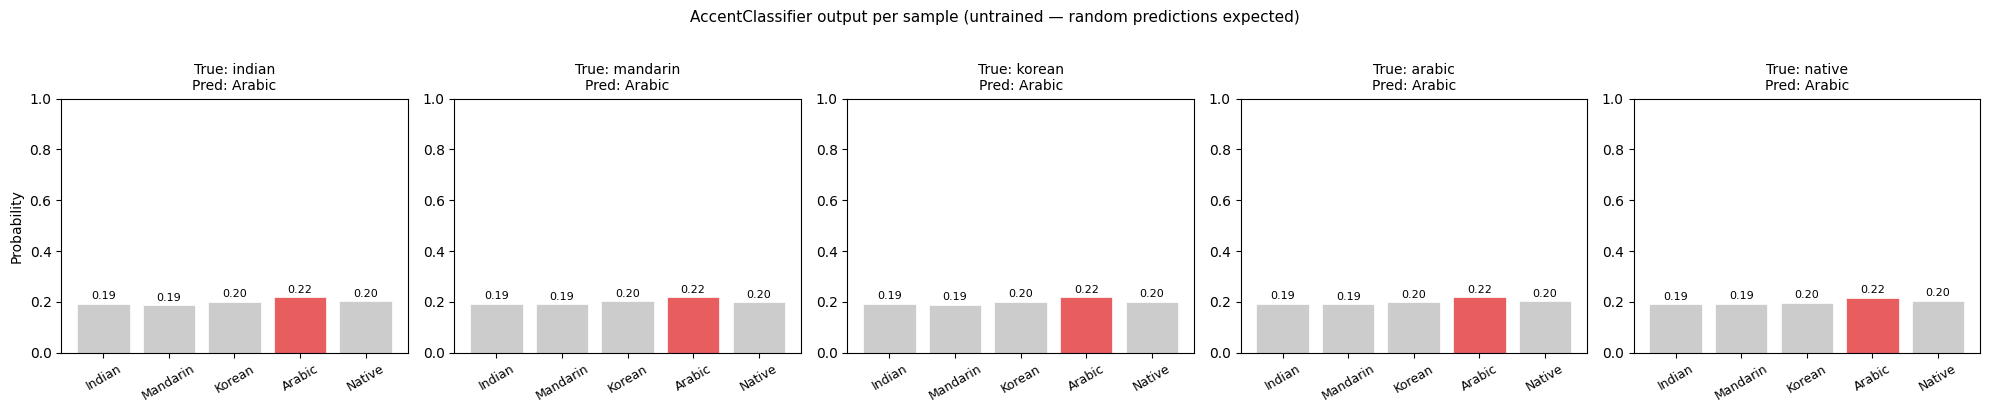

Saved → task3_accent_probs.png


In [ ]:
#newcode
import matplotlib.pyplot as plt

accent_names = ['Indian', 'Mandarin', 'Korean', 'Arabic', 'Native']
colors       = ['#4C8BE8', '#E8904C', '#5DBE7A', '#E85D5D', '#9B59B6']

fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for i, ax in enumerate(axes):
    probs     = accent_probs[i].cpu().detach().numpy()
    true_acc  = ACCENT_MAP[real_acc_ids[i]]
    pred_acc  = accent_names[probs.argmax()]

    bar_colors = ['#E85D5D' if j == probs.argmax() else '#CCCCCC'
                  for j in range(len(accent_names))]

    bars = ax.bar(accent_names, probs, color=bar_colors, edgecolor='white', linewidth=0.5)

    ax.set_ylim(0, 1)
    ax.set_ylabel('Probability' if i == 0 else '')
    ax.set_title(f'True: {true_acc}\nPred: {pred_acc}', fontsize=10)
    ax.tick_params(axis='x', rotation=30, labelsize=9)

    for bar, p in zip(bars, probs):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{p:.2f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('AccentClassifier output per sample (untrained — random predictions expected)',
             fontsize=11, y=1.02)

plt.tight_layout()
plt.savefig('task3_accent_probs.png', dpi=150, bbox_inches='tight')
plt.show()

print('Saved → task3_accent_probs.png')

---
## Cell 12 — Full AccentProcessor module (packaged for team handoff)
> Wraps all three Task 3 components into one module. This is what gets imported in Phase 2.

In [ ]:
#newcode
class AccentProcessor(nn.Module):
    """
    Full Task 3 module — wraps AccentProjectionHead, AccentClassifier,
    and accent_swap into one callable.

    Usage in Phase 2:
        processor = AccentProcessor().to(device)
        outputs   = processor(encoder_output, content_vec)

    Returns dict:
        'accent_vector'  : [B, 128]    — raw accent embedding
        'probabilities'  : [B, 5]      — accent class probs → use for accent loss
        'swapped'        : [B, T, 384] — content+accent concat → feed to re-encoder
    """
    def __init__(self, encoder_dim=768, accent_dim=128,
                 content_dim=256, num_accents=5):
        super().__init__()
        self.accent_head   = AccentProjectionHead(encoder_dim, accent_dim)
        self.classifier    = AccentClassifier(accent_dim, num_accents)

    def forward(self, encoder_output, content_vector):
        """
        Args:
            encoder_output : [B, T, 768]  — from Whisper encoder
            content_vector : [B, T, 256]  — from ContentHead (Task 2)
        """
        accent_vec   = self.accent_head(encoder_output)           # [B, 128]
        probs        = self.classifier(accent_vec)                # [B, 5]
        swapped      = accent_swap(content_vector, accent_vec)    # [B, T, 384]
        return {
            'accent_vector' : accent_vec,
            'probabilities' : probs,
            'swapped'       : swapped,
        }


# ── Test the packaged module ──────────────────────────────────────
print('Testing AccentProcessor (packaged module)...')
accent_processor = AccentProcessor().to(device)

with torch.no_grad():
    outputs = accent_processor(encoder_output, content_vec)

print(f"  accent_vector : {outputs['accent_vector'].shape}")
print(f"  probabilities : {outputs['probabilities'].shape}")
print(f"  swapped       : {outputs['swapped'].shape}")

assert outputs['accent_vector'].shape == (B, 128)
assert outputs['probabilities'].shape == (B, 5)
assert outputs['swapped'].shape       == (B, T, 384)

print('\nAccentProcessor packaged module — all assertions passed')
print('\nReady to hand off to the team:')
print(f"   → swapped [B, T, 384]    to Person 2 (Phase 2 Re-encoder)")
print(f"   → probabilities [B, 5]   to Person 4 (accent classification loss)")

Testing AccentProcessor (packaged module)...
  AccentProjectionHead: Linear(768→128) → LayerNorm → ReLU → MeanPool
  AccentClassifier : Linear(128→64) → ReLU → Linear(64→5) → Softmax
  accent_vector : torch.Size([5, 128])
  probabilities : torch.Size([5, 5])
  swapped       : torch.Size([5, 1500, 384])

AccentProcessor packaged module — all assertions passed

Ready to hand off to the team:
   → swapped [B, T, 384]    to Person 2 (Phase 2 Re-encoder)
   → probabilities [B, 5]   to Person 4 (accent classification loss)


---
## Cell 13 — Save model checkpoint to Google Drive
> Saves the accent head and classifier weights to Drive so Phase 2 can load them.

In [ ]:
SAVE_DIR = '/content/drive/MyDrive/MirrorSpeech/checkpoints'
os.makedirs(SAVE_DIR, exist_ok=True)

checkpoint = {
    'accent_head_state'       : accent_head.state_dict(),
    'accent_classifier_state' : accent_classifier.state_dict(),
    'content_head_state'      : content_head.state_dict(),
    'config': {
        'encoder_dim'  : 768,
        'accent_dim'   : 128,
        'content_dim'  : 256,
        'swapped_dim'  : 384,
        'num_accents'  : 5,
        'accent_map'   : ACCENT_MAP,
    }
}

save_path = f'{SAVE_DIR}/task3_phase1_components.pt'
torch.save(checkpoint, save_path)

print(f'Checkpoint saved → {save_path}')
print(f'\nSaved components:')
print(f'  accent_head_state       — AccentProjectionHead weights')
print(f'  accent_classifier_state — AccentClassifier weights')
print(f'  content_head_state      — ContentHead weights')
print(f'  config                  — dimension metadata')
print(f'\nTo load in Phase 2:')
print(f"  ckpt = torch.load('{save_path}')")
print(f"  accent_head.load_state_dict(ckpt['accent_head_state'])")

Checkpoint saved → /content/drive/MyDrive/MirrorSpeech/checkpoints/task3_phase1_components.pt

Saved components:
  accent_head_state       — AccentProjectionHead weights
  accent_classifier_state — AccentClassifier weights
  content_head_state      — ContentHead weights
  config                  — dimension metadata

To load in Phase 2:
  ckpt = torch.load('/content/drive/MyDrive/MirrorSpeech/checkpoints/task3_phase1_components.pt')
  accent_head.load_state_dict(ckpt['accent_head_state'])


---
## Cell 14 — Final summary
> Confirms Task 3 Phase 1 is complete and lists what to communicate to the team.

In [ ]:
#newcode
print('=' * 60)
print('TASK 3 PHASE 1 — COMPLETE SUMMARY')
print('=' * 60)

print('\nComponents built and tested:')
print('   AccentProjectionHead  : encoder_output [B,T,768] → accent_vec [B,128]')
print('   accent_swap()         : content [B,T,256] + accent [B,128] → swapped [B,T,384]')
print('   AccentClassifier      : accent_vec [B,128] → probs [B,5]')
print('   AccentProcessor       : full packaged module combining all three')

print('\nIntegration verified:')
print('   Real audio batch used (not dummy data)')
print('   Task 1 data loading → Task 2 encoder → Task 3 components')
print('   All tensor shapes correct')
print('   Probabilities sum to 1 for all samples')

print('\nNote:')
print('   Accent predictions are random — model is untrained.')
print('   Accuracy will improve after Phase 2 training (Task 7).')

TASK 3 PHASE 1 — COMPLETE SUMMARY

Components built and tested:
   AccentProjectionHead  : encoder_output [B,T,768] → accent_vec [B,128]
   accent_swap()         : content [B,T,256] + accent [B,128] → swapped [B,T,384]
   AccentClassifier      : accent_vec [B,128] → probs [B,5]
   AccentProcessor       : full packaged module combining all three

Integration verified:
   Real audio batch used (not dummy data)
   Task 1 data loading → Task 2 encoder → Task 3 components
   All tensor shapes correct
   Probabilities sum to 1 for all samples

Note:
   Accent predictions are random — model is untrained.
   Accuracy will improve after Phase 2 training (Task 7).
